In [1]:
import sys
import shutil
from pathlib import Path

#Add the project root to the Python path
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import pandas as pd
import matplotlib.pyplot as plt

# --- Output path config ---
ASSETS_DIR = project_root / "assets"
REPORTS_DIR = project_root / "reports" / "figures"
ALSO_SAVE_REPORTS = False  # set True to also copy into reports/figures/

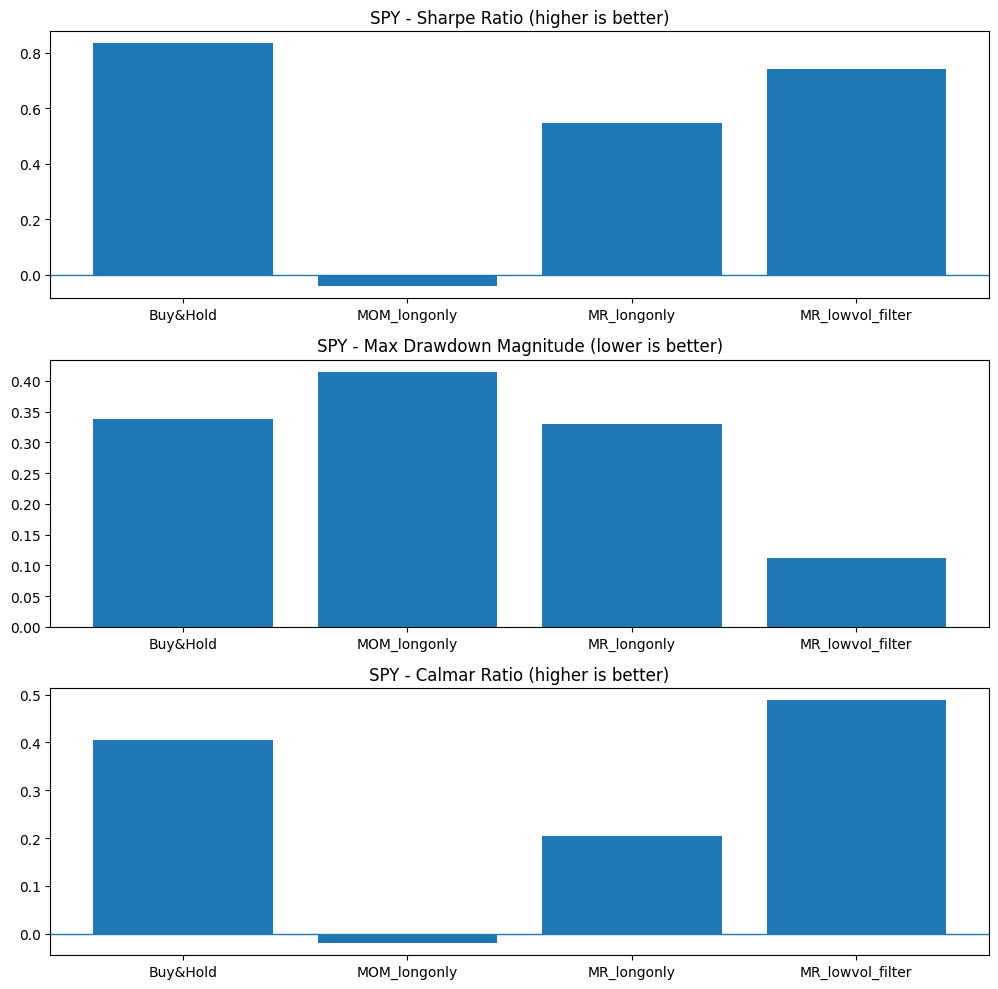

Saved: reports/figures/SPY_linkedin_summary.png


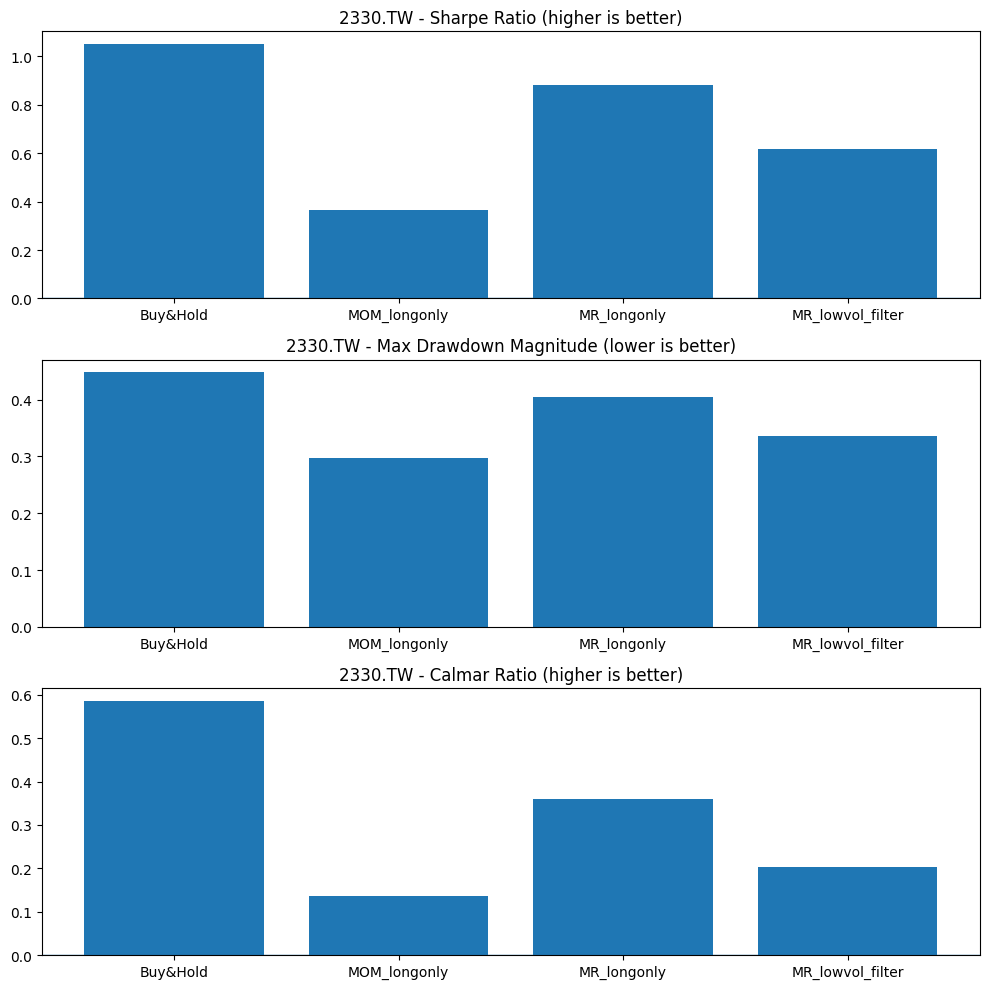

Saved: reports/figures/2330.TW_linkedin_summary.png


In [2]:
df = pd.read_csv("reports/summary_metrics.csv")

# Make MaxDD as "Drawdown Magnitude" as it will be more intuitive (the smaller, then better)
df["MaxDD_abs"] = df["MaxDD"].abs()

symbols = df["Symbol"].unique().tolist()

for sym in symbols:
    sub = df[df["Symbol"] == sym].copy()

    # Sort to let the baseline be the first one
    order = ["Buy&Hold", "MOM_longonly", "MR_longonly", "MR_lowvol_filter"]
    sub["Strategy"] = pd.Categorical(sub["Strategy"], categories=order, ordered=True)
    sub = sub.sort_values("Strategy")

    # One figure to show 3 bar charts (same figure, different panels)
    fig, axes = plt.subplots(3, 1, figsize=(10, 10))

    axes[0].bar(sub["Strategy"].astype(str), sub["Sharpe"])
    axes[0].set_title(f"{sym} - Sharpe Ratio (higher is better)")
    axes[0].axhline(0, linewidth=1)

    axes[1].bar(sub["Strategy"].astype(str), sub["MaxDD_abs"])
    axes[1].set_title(f"{sym} - Max Drawdown Magnitude (lower is better)")

    axes[2].bar(sub["Strategy"].astype(str), sub["Calmar"])
    axes[2].set_title(f"{sym} - Calmar Ratio (higher is better)")
    axes[2].axhline(0, linewidth=1)

    plt.tight_layout()
    ASSETS_DIR.mkdir(parents=True, exist_ok=True)
    outpath = ASSETS_DIR / f"{sym}_linkedin_summary.png"
    plt.savefig(outpath, dpi=250)
    if ALSO_SAVE_REPORTS:
        REPORTS_DIR.mkdir(parents=True, exist_ok=True)
        shutil.copy2(outpath, REPORTS_DIR / f"{sym}_linkedin_summary.png")
    plt.show()

    print("Saved:", outpath)